# Installation des librairies importantes et importation des données

In [17]:
# Install the ultralytics package using pip
!pip install -q ultralytics

from ultralytics import YOLO
from matplotlib import pyplot as plt
from PIL import Image

def learning_curve(pth_result):
  import pandas as pd
  df = pd.read_csv(pth_result)
  Y_train = df['train/box_loss']+df['train/cls_loss']+df['train/dfl_loss']
  Y_val = df['val/box_loss']+df['val/cls_loss']+df['val/dfl_loss']
  X = df['epoch']
  import matplotlib.pyplot as plt
  plt.plot(X,Y_train,label='train')
  plt.plot(X,Y_val,label='val')
  plt.xlabel('epoch')
  plt.ylabel('loss')
  plt.legend()
  plt.show()

In [2]:
HOME = '/content/'
!mkdir {HOME}/Detection
%cd {HOME}/Detection

!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="lOVTQ88BgSlHqrup7AYi")
project = rf.workspace("dissertation-bqltf").project("apple-detection-tg6vd")
dataset = project.version(1).download("yolov8")

/content/Detection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 127.8 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Apple-Detection-1 in yolov8:: 100%|██████████| 2014/2014 [00:00<00:00, 2160.80it/s]


# Composition des images dans la base d'entrainement, validation et test

In [3]:
import os
path_dataset = '/content/Detection/Apple-Detection-1'
for ix in os.listdir(path_dataset):
  if os.path.isdir(os.path.join(path_dataset,ix)):
    s=0
    for ids in os.listdir(os.path.join(path_dataset,ix,'images')):
      if os.path.isfile(os.path.join(path_dataset,ix,'images',ids)):
        s+=1
    print(ix,s)

test 331
valid 100
train 570


# Apprentissage

Paramètre ci-dessous à changer:
- model=

Vous avez le choix de: yolo11n, yolo11m

- batch= nombre de batch
- epochs= nombre depoch
- lr0= taux dapprentissage

In [9]:
!yolo task=detect mode=train model=yolo11m.pt data='/content/Detection/Apple-Detection-1/data.yaml' imgsz=720 plots=True patience=5 batch=2 epochs=10 lr0=0.0001 mosaic=0.0 mixup=0.0

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Detection/Apple-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=720, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, 

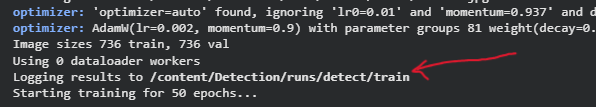

Le flèche rouge vous indique le chemin où est sauvegarder les sorties de votre entrainement : courbes d'apprentissage, échantillon d'objets prédites, meilleur modèle sauvegardé

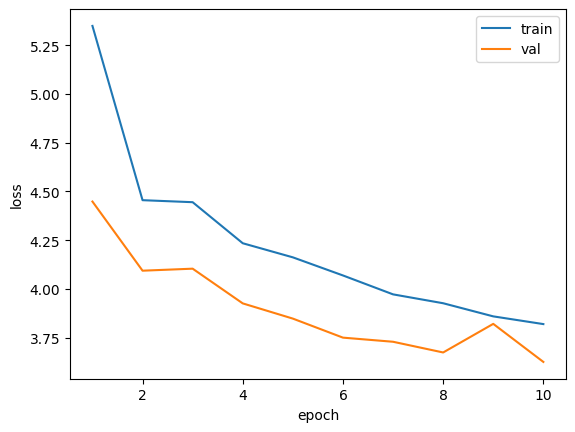

In [18]:
pth_result = '/content/Detection/runs/detect/train/results.csv'
learning_curve(pth_result)

# Evaluation

Ici, on évalue le meilleur modèle obtenu au-dessus sur les images test.

Paramètre ci-dessous à changer:
- model= chemin vers le /weights/best.pt
- conf= garder les boites ayant une conf au-dessus du seuil

In [10]:
!yolo val model='/content/Detection/runs/detect/train/weights/best.pt' data='/content/Detection/Apple-Detection-1/data.yaml' split=test imgsz=640 batch=16 conf=0.25 iou=0.6

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2580.2±350.9 MB/s, size: 235.9 KB)
val: Scanning /content/Detection/Apple-Detection-1/test/labels.cache... 331 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 331/331 4.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 2.9it/s 7.3s
                   all        331      12285       0.82      0.578      0.723      0.428
Speed: 1.3ms preprocess, 3.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/Detection/runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val
